# SSY098
## Lab 1: Image classification and detection
In this lab, you will acquaint yourself with simple, but powerful techniques for image classification and detection of objects in images. Although modern algorithms are often hugely complex pipelines built on neural networks, surprisingly fast and efficient results may be achieved with the simple tools you have been taught so far.

Specifically, you will use the skills developed in the lectures on
- Image filtering
- Image features

to create a covariance similarity filter for the detection of blood cells, creating local features based on a template. You will also do image-level classification of churches based on SIFT image features.

**Observe**: You should not install any other packages than the ones given in the pre-amble. You are expected to yourself look up documentation of given functions from libraries, e.g. OpenCV. You are allowed to use any methods in the packages that you see fit to solve the problems. It is highly encouraged to look at the documentation and search for usage instructions online, before asking for help.

**Observe**: Write your answers to questions directly in the cells denoted with **Your answer**.

## Submission Requirements:
Your final lab submission should include:
1. Your executed **notebook file** (`.ipynb`).
3. A **HTML printout** of the executed notebook with all outputs visible. 

First, we will import a set of python packages you will need for this lab.

In [2]:
# Pre-amble
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2 as cv
import os
from glob import glob
from typing import Tuple

## Task 1: Blood cell classification with template classifier
The objective of this task is to run a template classifier based on image similarity in order to detect blood cells. We will use a set of extracted blood cell patches (`data/bloodcells/training_data.npz`) of foreground cells, and background patches to fit a similarity filter.

The similarity filter will then be applied with sliding dot product to a microscopy test image (`data/bloodcells/test_images/088.png`) of many cells, in order to find as many individual cells as possible.

### Task 1.1
Create a function to read an image from a path to grayscale.

In [3]:
def read_as_grayscale(image_path: str) -> np.ndarray:
    """Reads an image from the specified path and converts it to grayscale.

    Args:
        image_path (str): The path to the image file.
    Returns:
        np.ndarray: A 2D array representing the grayscale image normalized to [0,1].
    """
    image = cv.imread(image_path, cv.IMREAD_GRAYSCALE)
    return image.astype(np.float32) / 255.0


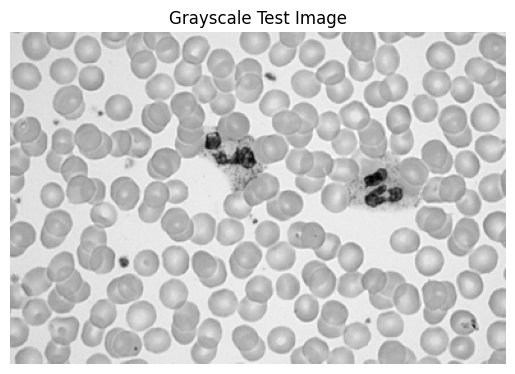

In [4]:
# Load a test image for blood cell counting
image = read_as_grayscale('data/bloodcells/test_images/088.png')

f, ax = plt.subplots()
ax.imshow(image, cmap='gray')
ax.set_title("Grayscale Test Image")
ax.axis('off')
plt.show()

### Task 1.2
Load `data/bloodcell.npz`, which is a set of patches containing blood cells.

In [5]:
data = np.load('data/bloodcells/training_data.npz', allow_pickle=True)
pos_patches = np.stack(data['fg_patches']) # positive examples
neg_patches = np.stack(data['bg_patches']) # negative examples
nbr_pos = len(pos_patches) # number of positive patches
nbr_neg = len(neg_patches) # number of negative patches
print(f'Number of samples: {nbr_pos+nbr_neg}')

Number of samples: 400


Display some positive and negative examples. Based on the displayed examples, how do you think the positive and negative examples were selected?

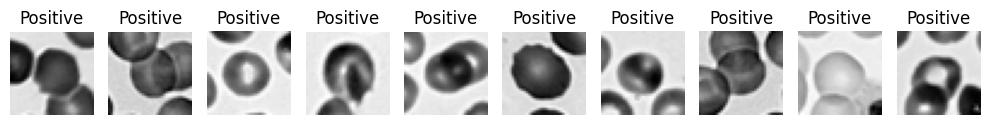

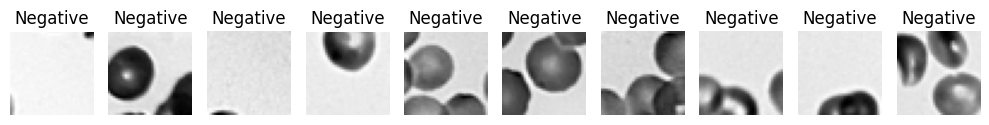

In [6]:
n_to_display = 10
idxs = np.random.choice(nbr_pos, n_to_display, replace=False)
f, ax = plt.subplots(1, 10, figsize=(10, 25))
for i in range(n_to_display):
    ax[i].imshow(pos_patches[idxs[i]], cmap='gray')
    ax[i].set_title("Positive")
    ax[i].axis('off')

plt.tight_layout()
plt.show()

f, ax = plt.subplots(1, 10, figsize=(10, 25))
for i in range(n_to_display):
    ax[i].imshow(neg_patches[idxs[i]], cmap='gray')
    ax[i].set_title("Negative")
    ax[i].axis('off')

plt.tight_layout()
plt.show()

**Your answer:**

From the displayed example images, it appears to me that the positive samples were selected primarily on the location of the cell in the patch. Positive patches have the cell positioned clearly in the center of the patch while the negative patches have their cells off-center, primarily on the edges of the image. This makes sense. We want our filter to search for a specific shape and appearance in the main image using a reference. If the reference patch does not have the desired object positioned in the patch in such a way that it is completely encompassed and centered, then we will match on incorrect patches of the original image like edges and corners of the object. Therefore, in this case we have selected positive samples where the cell is clearly observable and centered, while negative images have cell edges and off-center cells.


### Task 1.3
A similarity filter $w$ based on the average positive example may be defined via the image covariance (see Lecture 1: Course introduction)


$$
w = \frac{1}{HW}(\bar J - \mu_J)
$$

where $\bar J$ is the average of positive examples $\{J_k\}$, $\mu_{\bar J}$ is the pixelwise average of $\bar J$, and $H,W$ is the height and width. The similarity of the average positive example $\bar J$ to a new example $I$ is then

$$
\mathrm{similarity} = I \cdot w
$$

where $\cdot$ denotes the scalar product. In order to know what features a filter based on the positive patches will match, we should first inspect the average positive patch.

Compute an average cell from the positive and negative examples and display them.

In [7]:
def average_image(images: np.ndarray) -> np.ndarray:
    """
    Computes the average image from a set of images.

    Args:
        images (np.ndarray): A 3D array of shape (N, H, W) where N is the number of images, H is the height, and W is the width.

    Returns:
        np.ndarray: A 2D array of shape (H, W) representing the average image.
    """
    return np.mean(images, axis=0)

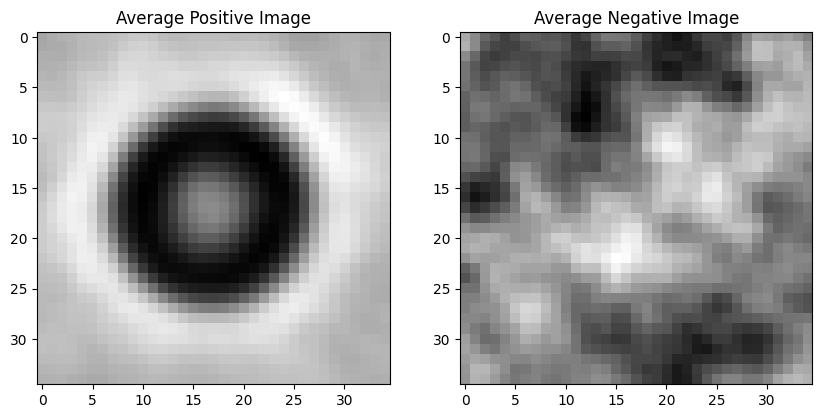

In [8]:
avg_pos = average_image(pos_patches)
avg_neg = average_image(neg_patches)

f, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(avg_pos, cmap='gray')
ax[0].set_title('Average Positive Image')
ax[1].imshow(avg_neg, cmap='gray')
ax[1].set_title('Average Negative Image')
plt.show()

### Task 1.4
Make a function that creates a similarity filter based on the set of positive examples. 

Also create a function to apply the similarity filter to a given image.

We may classify a given patch $I$ using our filter $w$ using a simple threshold $\tau$, i.e.

$$
y = I\cdot w \geq \tau = \begin{cases}
1,\quad \text{if foreground} \\
0,\quad \text{if background}
\end{cases}
$$

Test the filter on the positive and negative examples with a threshold  $\tau = 0$. How many misclassified examples do you get?

In [17]:
def create_covariance_filter(images: np.ndarray) -> np.ndarray:
    """
    Creates a covariance filter from a set of images.

    Args:
        images (np.ndarray): A 3D array of shape (N, H, W) where N is the number of images, H is the height, and W is the width.
    
    Returns:
        np.ndarray: A 2D array of shape (H, W) representing the covariance filter.
    """
    _, h, w = images.shape
    J_hat = np.mean(images, axis=0)
    mu_j = np.mean(images.flatten())

    return (1/(h*w)) * (J_hat - mu_j)
    

def apply_filter_to_patch(image: np.ndarray, filter: np.ndarray) -> np.ndarray:
    """
    Applies a similarity filter to a full image or patch.

    Args:
        image (np.ndarray): A 2D array of shape (H, W) representing the input image.
        filter (np.ndarray): A 2D array of shape (h, w) representing the filter to be applied.
    
    Returns:
        np.ndarray: A 2D array of shape (H, W) representing the filtered image.
    """
    k_size, _ = filter.shape
    h, w = image.shape

    num_column_passes = w - k_size + 1
    num_row_passes = h - k_size + 1

    response_map = np.zeros((num_row_passes, num_column_passes))

    for r in range(num_row_passes):
        for c in range(num_column_passes):
            response_map[r, c] = np.sum(image[r:r+k_size, c:c+k_size] * filter)

    return response_map[0]

In [18]:
# Create covariance filter
w = create_covariance_filter(pos_patches)

# Test it on the full data with threshold = 0
threshold    = 0
positive_sim = []
for p in pos_patches:
    positive_sim.append(apply_filter_to_patch(p, w))

positive_sim = np.array(positive_sim)

negative_sim = []
for n in neg_patches:
    negative_sim.append(apply_filter_to_patch(n, w))

negative_sim = np.array(negative_sim)

# Classify the samples based on the threshold
# True Positives (TP): Positive samples correctly classified as positive
true_positives = np.sum(positive_sim >= threshold)
# False Negatives (FN): Positive samples incorrectly classified as negative
false_negatives = np.sum(positive_sim < threshold)
# True Negatives (TN): Negative samples correctly classified as negative
true_negatives = np.sum(negative_sim < threshold)
# False Positives (FP): Negative samples incorrectly classified as positive
false_positives = np.sum(negative_sim >= threshold)

# Compute the number of misclassified samples for this threshold
nbr_misclassified = false_negatives + false_positives
print(f'Number of misclassified samples at threshold {threshold}: {nbr_misclassified}')


Number of misclassified samples at threshold 0: 65


 ### Task 1.5
 Given a set of training images and a fixed similarity filter $w$, can you suggest an efficient method to find the best $\tau$?

**Your answer:**

In this case since we are looking to find the $\tau$ that minimizes the number of misclassified samples while still being able to generalize to unseen samples. Therefore, we could use a cross validation technique where we first split the available training images into a test and train subset. Then using k-fold cross validation we could evaluate the effects of changing $\tau$ while preventing us from overfitting by selecting a $\tau$ that performs optimally on the full training set. Finally, we could evaluate our chosen $\tau$ on the held out test set as a final performance evaluation. Here I am considering the performance metric to be the number of misclassfied patches which we ideally want to be zero across all folds and the test set. 

The cross validation would be applied across a discretization of the $\tau$ value between two values (can be taken as min and max on full training split) where the number of steps can be chosen for granularity of the search.

Due to the low number of images in our training set, this method is quite efficient and works well to prevent an overfitting situation by choosing the best $\tau$ for the training set. However, if we have very many images this method could become computationally expensive. In this situation we could reduce the computational demand by for example, lowering the number of folds in k-folds, decreasing the granularity of our discretization of $\tau$, choosing to use one train-test split instead of k-fold, or a combination of all aforementioned.  

### Task 1.6
There will always be a compromise between the number of correctly classified samples vs. the misclassified ones. In binary classification, it is common to define
- $\mathrm {TP}$ as the number of true positives (the number of correctly classified positive samples)
- $\mathrm{FP}$ as the number of false positives (negatives incorrectly classified as positive)
- $\mathrm{TN}$ as the number of true negatives (the number of correctly classified negative samples)
- $\mathrm{FN}$ as the number of false negatives (positives incorrectly classified as negative)

These may be summarized as a confusion matrix - create a function that computes the confusion matrix for a given threshold.


In [19]:
def confusion_matrix(positive_sim: np.ndarray, negative_sim: np.ndarray, threshold: float) -> np.ndarray:
    """
    Computes the confusion matrix for a given threshold.

    Args:
        positive_sim (np.ndarray): An array of similarity scores for positive samples.
        negative_sim (np.ndarray): An array of similarity scores for negative samples.
        threshold (float): The threshold for classification.

    Returns:
        np.ndarray: A 2x2 confusion matrix where:
                    [[TP, FN],
                     [FP, TN]]
    """
    true_positives = np.sum(positive_sim >= threshold)
    false_negatives = np.sum(positive_sim < threshold)
    true_negatives = np.sum(negative_sim < threshold)
    false_positives = np.sum(negative_sim >= threshold)

    return np.array([[true_positives, false_negatives],[false_positives, true_negatives]])


[[200   0]
 [ 65 135]]


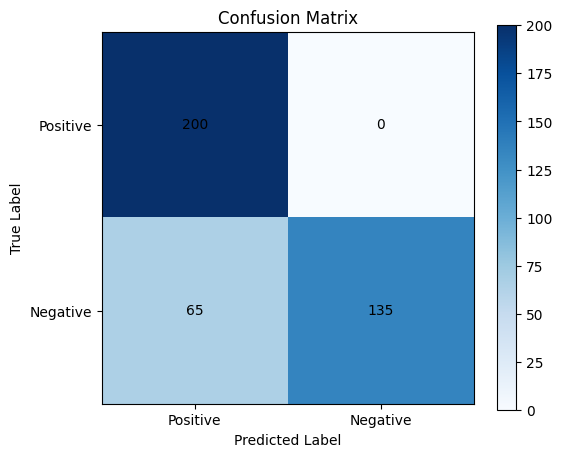

In [20]:
# Make a confusion matrix
cm = confusion_matrix(positive_sim, negative_sim, threshold)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks([0, 1], ['Positive', 'Negative'])
plt.yticks([0, 1], ['Positive', 'Negative'])
plt.colorbar()

# Add text annotations
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.show()

### Task 1.7
Let us say we are interested in avoiding missing positive cells - certainly a desirable goal in this case. In that case, we may try to optimize either the $\mathrm{TP}$ rate or the $\mathrm{recall}$. The latter, $\mathrm{recall}$ emphasizes finding true positives, and is often complemented by $\mathrm{precision}$, which on the other hand tries to minimize false positives. They are defined such that
$$
\mathrm{recall} = \frac{\mathrm {TP}}{\mathrm {P}} = \frac{\mathrm {TP}}{\mathrm {TP} + \mathrm {FN}}, \quad \mathrm{precision} = \frac{\mathrm{TP}}{\mathrm{TP} + \mathrm{FP}}
$$

Define a function to compute the recall and precision from the confusion matrix.

You should also make a function `score_at_threshold` that computes a set of either recall or precision scores for an array of threshold values. You should pass the score function itself as the final parameter. Lastly, make a function `optimal_score_index` which finds the index of the highest score.

In [21]:
def recall_score(conf_matrix: np.ndarray) -> float:
    """
    Computes the recall score from a confusion matrix.

    Args:
        conf_matrix (np.ndarray): A 2x2 confusion matrix where:
                                  [[TP, FN],
                                   [FP, TN]]
    Returns:
        float: The recall score.
    """
    return conf_matrix[0,0] / (conf_matrix[0,0] + conf_matrix[0,1])

def precision_score(conf_matrix: np.ndarray) -> float:
    """
    Computes the precision score from a confusion matrix.

    Args:
        conf_matrix (np.ndarray): A 2x2 confusion matrix where:
                                  [[TP, FN],
                                   [FP, TN]]
    Returns:
        float: The precision score.
    """
    return conf_matrix[0,0] / (conf_matrix[0,0] + conf_matrix[1,0])

def score_at_threshold(positive_sim: np.ndarray, negative_sim: np.ndarray, threshold: np.ndarray, score_fn: callable) -> np.ndarray:
    """
    Computes the scores from each confusion matrix for a set of given thresholds.

    Args:
        positive_sim (np.ndarray): An array of similarity values for positive samples.
        negative_sim (np.ndarray): An array of similarity values for negative samples.
        threshold (np.ndarray): A 1xN array of thresholds to evaluate.
        score_fn (callable): A function that computes the score from a confusion matrix.

    Returns:
        np.ndarray: A 1xN array containing the score at each threshold.
    """
    scores = []
    
    for t in threshold:
        scores.append(score_fn(confusion_matrix(positive_sim, negative_sim, t)))

    return np.array(scores)

def optimal_score_index(scores: np.ndarray) -> int:
    """
    Finds the index that maximizes an array of scores.

    Args:
        scores (np.ndarray): A 1xN array containing the scores at each threshold.

    Returns:
        int: The index of the threshold that maximizes the score.
    """
    return np.argmax(scores)

Here we let the guess of potential threshold values simply be a set of evenly spaced similarities from the minimum recorded to the maximum recorded ones on the training set. If one has a better guess _a priori_ (say, 0-1 for certain tasks), that could also be used.

Compare the resulting confusion matrices from the optimal recall and precision. Which is the best score?

In [22]:
# Use the set of similarity scores as thresholds
thresholds = np.linspace(min(np.min(negative_sim), np.min(positive_sim)), max(np.max(negative_sim), np.max(positive_sim)), num=100)
precisions = score_at_threshold(positive_sim, negative_sim, thresholds, precision_score)
recalls    = score_at_threshold(positive_sim, negative_sim, thresholds, recall_score)

# Compute the best threshold that maximizes the scores
best_precision_index = optimal_score_index(precisions)
best_precision_threshold = thresholds[best_precision_index]

best_recall_index = optimal_score_index(recalls)
best_recall_threshold = thresholds[best_recall_index]

print(f'Best precision threshold: {best_precision_threshold} with score {precisions[best_precision_index]}')
print(f'Best recall threshold: {best_recall_threshold} with score {recalls[best_recall_index]}')


Best precision threshold: 0.0018319057540977179 with score 0.9791666666666666
Best recall threshold: -0.001967142275095558 with score 1.0


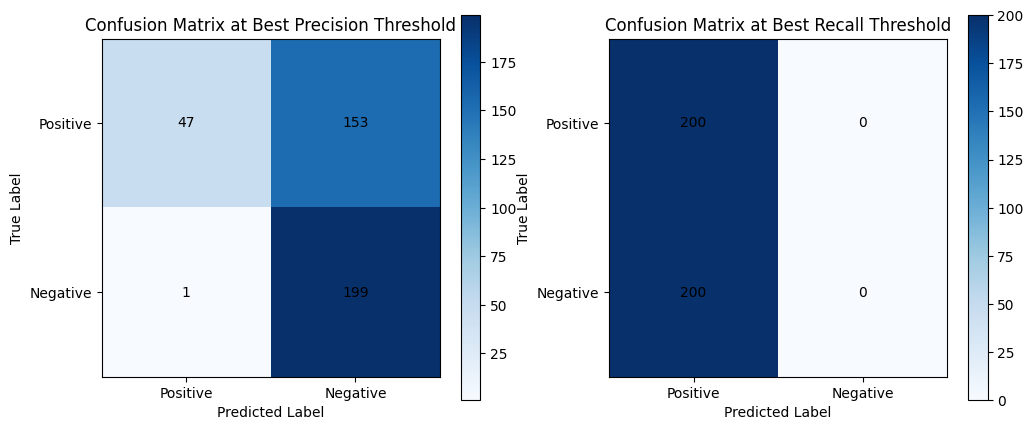

In [23]:
# Make a confusion matrix at the best threshold
cm_precision = confusion_matrix(positive_sim, negative_sim, best_precision_threshold)
cm_recall = confusion_matrix(positive_sim, negative_sim, best_recall_threshold)

f, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(cm_precision, cmap='Blues')
ax[0].set_title('Confusion Matrix at Best Precision Threshold')
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('True Label')
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(['Positive', 'Negative'])
ax[0].set_yticks([0, 1])
ax[0].set_yticklabels(['Positive', 'Negative'])
ax[1].imshow(cm_recall, cmap='Blues')
ax[1].set_title('Confusion Matrix at Best Recall Threshold')
ax[1].set_xlabel('Predicted Label')
ax[1].set_ylabel('True Label')
ax[1].set_xticks([0, 1])
ax[1].set_xticklabels(['Positive', 'Negative'])
ax[1].set_yticks([0, 1])
ax[1].set_yticklabels(['Positive', 'Negative'])
plt.colorbar(ax[0].imshow(cm_precision, cmap='Blues'), ax=ax[0])
plt.colorbar(ax[1].imshow(cm_recall, cmap='Blues'), ax=ax[1])

# Add text annotations
for i in range(cm_precision.shape[0]):
    for j in range(cm_precision.shape[1]):
        ax[0].text(j, i, cm_precision[i, j], ha='center', va='center', color='black')

for i in range(cm_recall.shape[0]):
    for j in range(cm_recall.shape[1]):
        ax[1].text(j, i, cm_recall[i, j], ha='center', va='center', color='black')


**Your answer:**


### Task 1.8
A common alternative is to use a balance of precision and recall. We may choose the optimal threshold using $F_1$ score, which balances true positives with false positives and negatives and is easy to compute:

$$
F_1 = \frac{2}{\mathrm{recall}^{-1} + \mathrm{precision}^{-1}} = \frac{2\mathrm{TP}}{2\mathrm{TP} + \mathrm{FP} + \mathrm{FN}}.
$$

Write a scoring function for $F_1$ using the confusion matrix.

In [24]:
def f1_score(conf_matrix: np.ndarray) -> float:
    """
    Computes the F1 score from a confusion matrix.

    Args:
        conf_matrix (np.ndarray): A 2x2 confusion matrix where:
                                  [[TP, FN],
                                   [FP, TN]]
    Returns:
        float: The F1 score computed from the confusion matrix.
    """
    return ((2 * conf_matrix[0,0]) / (2 * conf_matrix[0,0] + conf_matrix[1,0] + conf_matrix[0,1]))

In [25]:
# Use the set of similarity scores as thresholds
thresholds = np.linspace(min(np.min(negative_sim), np.min(positive_sim)), max(np.max(negative_sim), np.max(positive_sim)), num=100)
f1s = score_at_threshold(positive_sim, negative_sim, thresholds, f1_score)

# Compute the best threshold that maximizes the scores
best_f1_index = optimal_score_index(f1s)
best_f1_threshold = thresholds[best_f1_index]

print(f'Best F1 threshold: {best_f1_threshold} with score {f1s[best_f1_index]}')


Best F1 threshold: 0.0003220276912132107 with score 0.9112149532710281


### Task 1.9
Study some failure cases for $F_1$ maximization. Why do you think your classifier may have failed for these cases?

Number of misclassified positive samples: 153
Number of misclassified negative samples: 1


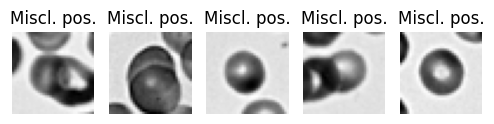

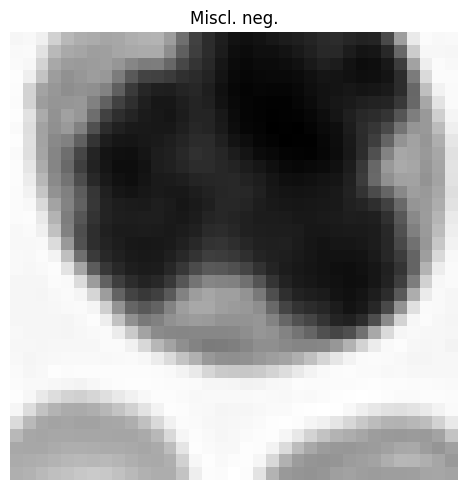

In [26]:
# Study failure cases
positive_sim = np.array([apply_filter_to_patch(patch, w) for patch in pos_patches])
negative_sim = np.array([apply_filter_to_patch(patch, w) for patch in neg_patches])
idx_pos_misclassified = np.where(positive_sim < best_precision_threshold)[0]
idx_neg_misclassified = np.where(negative_sim > best_precision_threshold)[0]

print(f"Number of misclassified positive samples: {len(idx_pos_misclassified)}")
print(f"Number of misclassified negative samples: {len(idx_neg_misclassified)}")

f, ax = plt.subplots(1, min(5, len(idx_pos_misclassified)), figsize=(5, 25))
for i in range(min(5, len(idx_pos_misclassified))):
    ax[i].imshow(pos_patches[idx_pos_misclassified[i]], cmap='gray')
    ax[i].set_title("Miscl. pos.")
    ax[i].axis('off')
plt.tight_layout()
plt.show()

f, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(neg_patches[idx_neg_misclassified[0]], cmap='gray')
ax.set_title("Miscl. neg.")
ax.axis('off')
plt.tight_layout()
plt.show()

**Your answer:**

From the misclassified positive images, which are clearly positive instances, it appears that the classifier fails to correctly classify as positive because of noisy cells surrounding the patch. The average positive sample image that is used to create the filter has a very clear cell in the center with very high intensity values (empty space) surrounding it. This indicates that the filter will produce higher similarity scores on patches with cells containing little to no surrounding cells. Comparing with the average negative sample filter, we observe a clear mixing of the intensity values with lower intensities (cells) lying along the edges of the patch. Therefore, with these observations, we can expect the classifier to more often misclassify positive samples as negative if they contain a lot of noise from other cells being on the edges and corners of the patch. This is observed in the 5 example misclassifications where each misclassification has some amount of lower intensity values surrounding the center cell. This idea is further confirmed when comparing the misclassified negative samples to our filters where the negative sample has very little noise with high intensity pixels surrounding a low intensity circular blob (cell) in the middle. It is clear that the misclassified negative sample matches the average positive filter over the negative filter.

In summary, the positive misclassifications arise because the noisy edges do not align well with the average positive samples filter resulting in low similarity scores. The negative misclassification arises due to the inverse alignment of being too similar to the average positive samples filter.

### Task 1.10
We will now apply the similarity built on patches on a full image. In order to identify the blood cells, apply your linear classifier with a dot product along a sliding window on the full image, i.e. cross-correlation.

Use the function `filter2D` from the package `cv2` to compute a similarity map with the image and your covariance filter. 

In [27]:
def filter_w_similarity(image: np.ndarray, filter: np.ndarray) -> np.ndarray:
    """
    Computes the similarity between an image and a filter using cross-correlation.

    Args:
        image (np.ndarray): A 2D array representing the input image.
        filter (np.ndarray): A 2D array representing the filter to be applied.

    Returns:
        np.ndarray: A 2D array representing the similarity between the image and the filter.
    """
    return cv.filter2D(image, -1, filter)

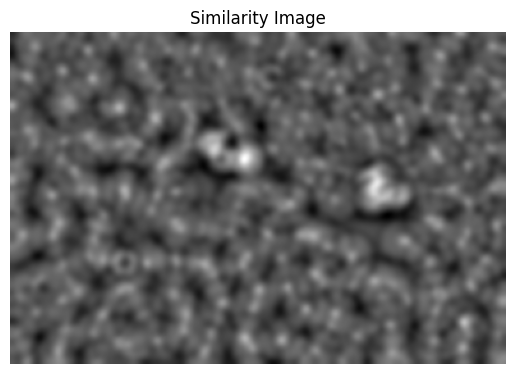

In [28]:
# Load a test image for blood cell counting
image = read_as_grayscale('data/bloodcells/test_images/088.png')

# Apply the linear classifier in a sliding window manner using cross-correlation
similarity_image = filter_w_similarity(image, w)

f, ax = plt.subplots()
ax.imshow(similarity_image, cmap='gray')
ax.set_title("Similarity Image")
ax.axis('off')
plt.show()


Threshold the image to find the highest similarity given your pre-computed threshold.

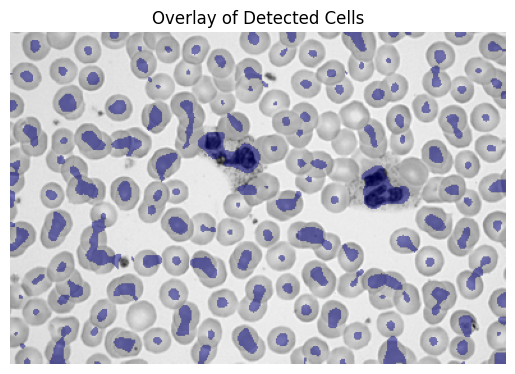

In [29]:
# Threshold the response image to detect cells
thresholded_response = similarity_image > best_f1_threshold

# Display the overlay
# Set mask to nan for better visualization
thresholded_response_masked = np.where(thresholded_response, 1, np.nan)
f, ax = plt.subplots()
ax.imshow(image, cmap='gray')
ax.imshow(thresholded_response_masked, cmap='jet', alpha=0.5)
ax.set_title('Overlay of Detected Cells')
ax.axis('off')
plt.show()

### Task 1.11
We know wish to localize the cells more finely, and also estimate their number. For this purpose, we will compute the maximum similarity using non-maximum suppression. We are interested in strict local maxima of the cell centres.

You are given the function `rank_filter(...,-2, size=neighbourhood_size)` which computes the second-to-highest intensity in a given filter neighbourhood. Use this to find the strictly largest similarity in the thresholded similarity map. The function should return the row and column coordinates for all maxima.

In [30]:
from scipy.ndimage import rank_filter

def strict_local_maxima(similarity_image: np.ndarray, threshold: float) -> np.ndarray:
    """
    Computes the coordinates of all strict local maxima in the response image.
    
    Args:
        similarity_image (np.ndarray): Input similarity image.
        threshold (float): The threshold for considering a similarity value as a potential detection.
    
    Returns:
        np.ndarray: 2 x n array with column coordinates in the first row
                     and row coordinates in the second row.
    """
    nhood_size = (3,3)
    next_best = rank_filter(similarity_image, -2, size=nhood_size)

    maximum_image = (similarity_image > next_best) & (similarity_image > threshold)
    coords = np.transpose(np.argwhere(maximum_image))

    return coords
    
    

Number of detected cells: 190


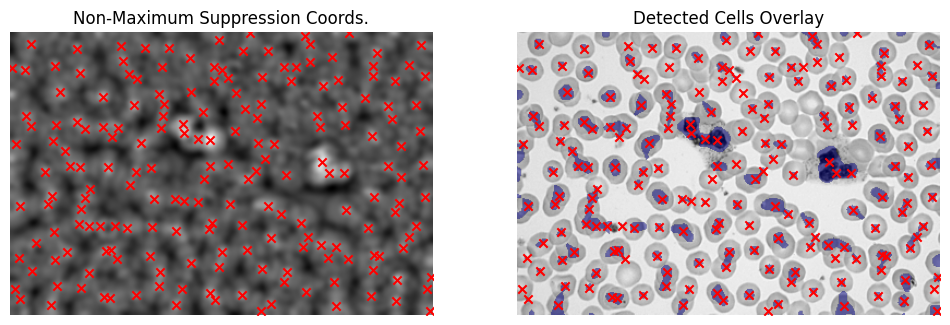

In [31]:
# Apply non-maximum suppression to the response image
maxima_coords = strict_local_maxima(similarity_image, best_f1_threshold)
print(f"Number of detected cells: {len(maxima_coords[0])}")
f, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(similarity_image, cmap='gray')
ax[0].scatter(maxima_coords[1], maxima_coords[0], color='red', marker='x')
ax[0].set_title('Non-Maximum Suppression Coords.')
ax[0].axis('off')
ax[1].imshow(image, cmap='gray')
ax[1].imshow(thresholded_response_masked, cmap='jet', alpha=0.5)
ax[1].scatter(maxima_coords[1], maxima_coords[0], color='red', marker='x')
ax[1].set_title('Detected Cells Overlay')
ax[1].axis('off')
plt.show()

### Task 1.13
Compile your functions into a `detector` that uses your linear classifier with non-maximum suppression to detect cell centres in an image. 

In [32]:
def detector(image: np.ndarray, w: np.ndarray, threshold: float) -> Tuple[np.ndarray, np.ndarray]:
    """
    Detects cell centers in an image using a linear classifier and non-maximum suppression.
    
    Args:
        image (np.ndarray): Input image
        w (np.ndarray): The covariance filter
        threshold (float): Threshold for classification
    
    Returns:
        np.ndarray: Cell centers.
        np.ndarray: Thresholded response image
    """
    similarity_image = filter_w_similarity(image, w)
    thresholded_response = similarity_image > threshold
    maxima_coords = strict_local_maxima(similarity_image, threshold)

    return (maxima_coords, thresholded_response)

### Task 1.15
Test your function `detector` on the images in `data/bloodcells/test_images`. 

In [33]:
def load_images_as_grayscale(root_path: str) -> list:
    """
    Loads a list of images from the specified paths and converts them to grayscale.

    Args:   
        root_path (str): The path to the directory containing the image files.
    Returns:
        list: A list of 2D numpy arrays representing the grayscale images.
    """
    grayscale_images = []
    
    image_paths = glob(f"{root_path}/*.png", recursive=True)
    for path in image_paths:
        grayscale_images.append(cv.imread(path, cv.IMREAD_GRAYSCALE).astype(np.float32) / 255.0)

    return grayscale_images
    

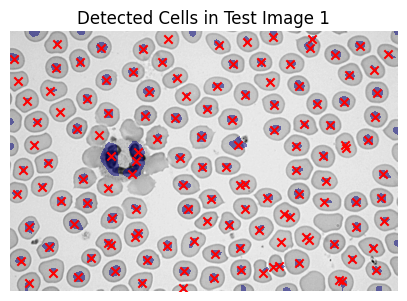

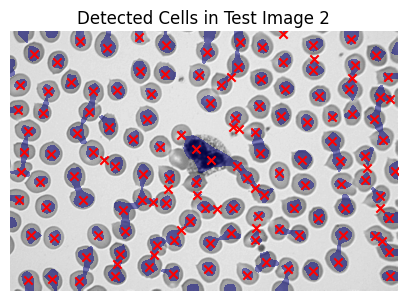

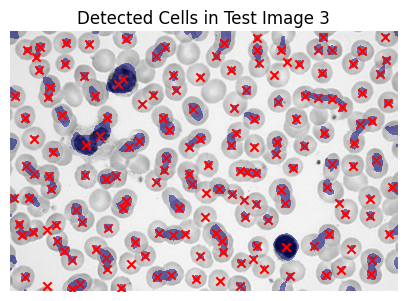

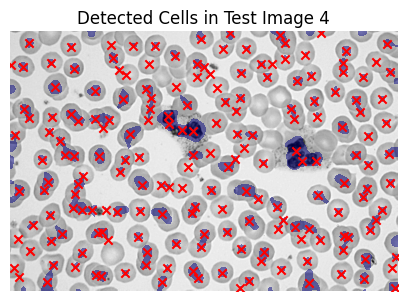

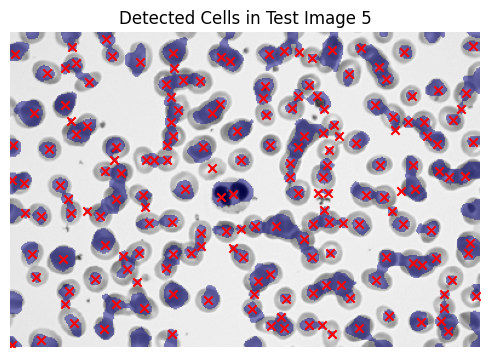

In [34]:
# Load and process all test images
images = load_images_as_grayscale('data/bloodcells/test_images')

for i, image in enumerate(images):

    # Detect cell centers
    centers, thresholded_response = detector(image, w, best_f1_threshold)

    # Display the results
    thresholded_response_masked = np.where(thresholded_response, 1, np.nan)

    f, ax = plt.subplots(1, 1, figsize=(5, 5))
    ax.imshow(image, cmap='gray')
    ax.axis('off')

    ax.imshow(thresholded_response_masked, cmap='jet', alpha=0.5)
    ax.scatter(centers[1], centers[0], color='red', marker='x')
    ax.set_title(f'Detected Cells in Test Image {i+1}')
plt.tight_layout()
plt.show()

## Task 2: Traffic sign classification with a template classifier
In this task, you will test the same method for a real-world task of traffic sign recognition. You will employ the exact same procedure as in previous tasks, and evaluate the aptness of the method.

### Task 2.1 
Use the functions you implemented in task 1 to construct a traffic sign classifier from the training images in `data/trafficsigns/training_images`, and apply it on the test images in `data/trafficsigns/test_images`. 

You should write code to load the training data, compute the average positive and negative patches and apply them as a similarity filter to the training data and compute the optimal threshold. Finally, you should load the test data and use your detector.

How would you say the similarity filter performs? Do you have any idea why?

### Test Image

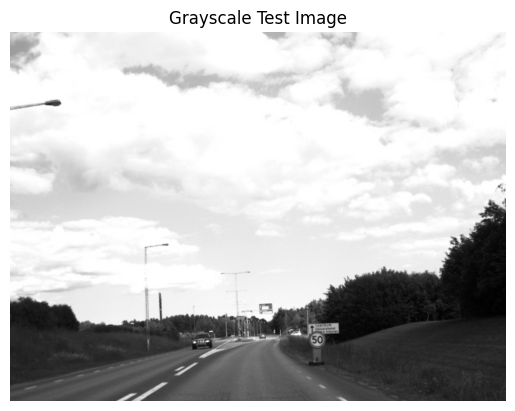

In [35]:
# Load a test image for traffic sign detection
image = read_as_grayscale('data/trafficsigns/test_images/img_1.png')

f, ax = plt.subplots()
ax.imshow(image, cmap='gray')
ax.set_title("Grayscale Test Image")
ax.axis('off')
plt.show()

### Loading Positive & Negative Patches

In [51]:
pos_patches = np.array(load_images_as_grayscale("data/trafficsigns/training_images/speed"))
neg_patches = np.array(load_images_as_grayscale("data/trafficsigns/training_images/bg"))

nbr_pos = len(pos_patches) # number of positive patches
nbr_neg = len(neg_patches) # number of negative patches
print(f'Number of samples: {nbr_pos+nbr_neg}')

Number of samples: 243


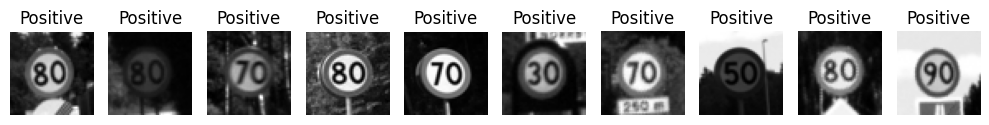

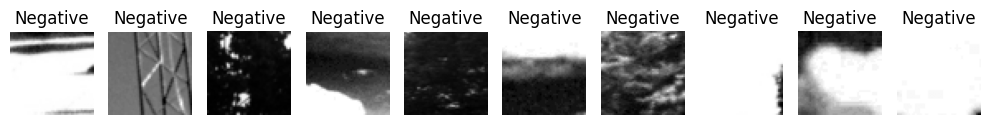

In [52]:
n_to_display = 10
idxs = np.random.choice(nbr_pos, n_to_display, replace=False)
f, ax = plt.subplots(1, 10, figsize=(10, 25))
for i in range(n_to_display):
    ax[i].imshow(pos_patches[idxs[i]], cmap='gray')
    ax[i].set_title("Positive")
    ax[i].axis('off')

plt.tight_layout()
plt.show()

idxs = np.random.choice(nbr_neg, n_to_display, replace=False)
f, ax = plt.subplots(1, 10, figsize=(10, 25))
for i in range(n_to_display):
    ax[i].imshow(neg_patches[idxs[i]], cmap='gray')
    ax[i].set_title("Negative")
    ax[i].axis('off')

plt.tight_layout()
plt.show()

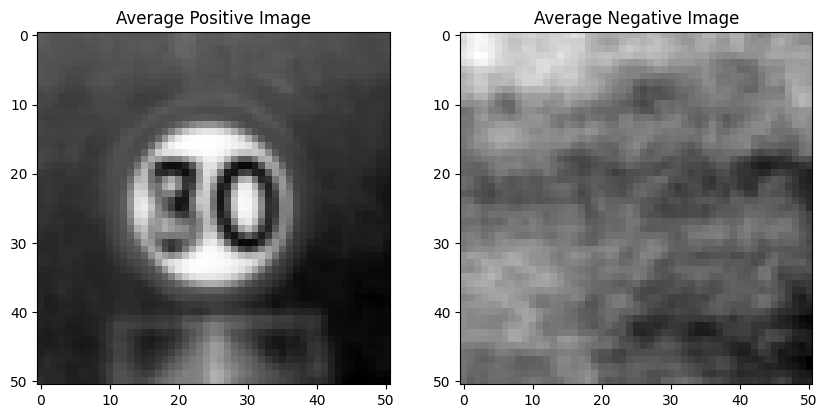

In [57]:
avg_pos = average_image(pos_patches)
avg_neg = average_image(neg_patches)

f, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(avg_pos, cmap='gray')
ax[0].set_title('Average Positive Image')
ax[1].imshow(avg_neg, cmap='gray')
ax[1].set_title('Average Negative Image')
plt.show()

In [58]:
w = create_covariance_filter(pos_patches)

positive_sim = []
for p in pos_patches:
    positive_sim.append(apply_filter_to_patch(p, w))

positive_sim = np.array(positive_sim)

negative_sim = []
for n in neg_patches:
    negative_sim.append(apply_filter_to_patch(n, w))

negative_sim = np.array(negative_sim)

# Use the set of similarity scores as thresholds
thresholds = np.linspace(min(np.min(negative_sim), np.min(positive_sim)), max(np.max(negative_sim), np.max(positive_sim)), num=100)
f1s = score_at_threshold(positive_sim, negative_sim, thresholds, f1_score)

# Compute the best threshold that maximizes the scores
best_f1_index = optimal_score_index(f1s)
best_f1_threshold = thresholds[best_f1_index]

print(f'Best F1 threshold: {best_f1_threshold} with score {f1s[best_f1_index]}')

Best F1 threshold: 0.0009282056449188125 with score 0.8814814814814815


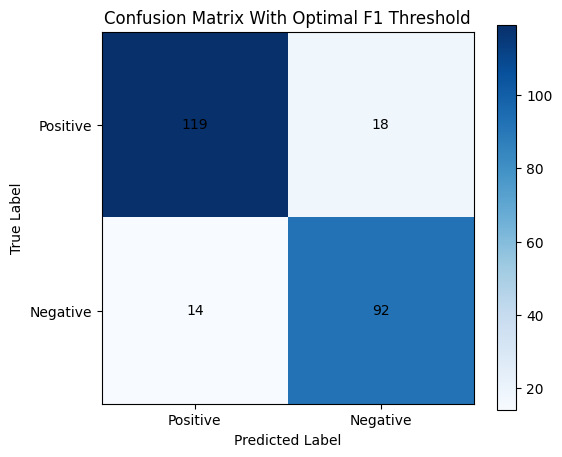

In [59]:
# Make a confusion matrix
cm = confusion_matrix(positive_sim, negative_sim, best_f1_threshold)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix With Optimal F1 Threshold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks([0, 1], ['Positive', 'Negative'])
plt.yticks([0, 1], ['Positive', 'Negative'])
plt.colorbar()

# Add text annotations
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.show()

Number of misclassified positive samples: 18
Number of misclassified negative samples: 14


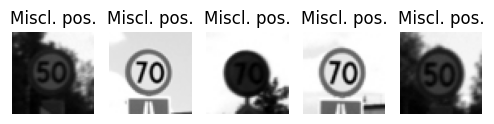

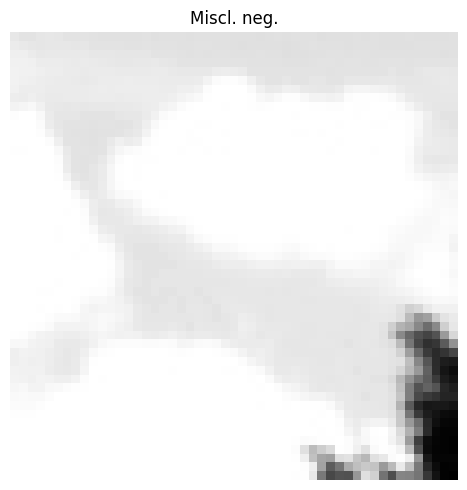

In [61]:
# Study failure cases
positive_sim = np.array([apply_filter_to_patch(patch, w) for patch in pos_patches])
negative_sim = np.array([apply_filter_to_patch(patch, w) for patch in neg_patches])
idx_pos_misclassified = np.where(positive_sim < best_f1_threshold)[0]
idx_neg_misclassified = np.where(negative_sim > best_f1_threshold)[0]

print(f"Number of misclassified positive samples: {len(idx_pos_misclassified)}")
print(f"Number of misclassified negative samples: {len(idx_neg_misclassified)}")

f, ax = plt.subplots(1, min(5, len(idx_pos_misclassified)), figsize=(5, 25))
for i in range(min(5, len(idx_pos_misclassified))):
    ax[i].imshow(pos_patches[idx_pos_misclassified[i]], cmap='gray')
    ax[i].set_title("Miscl. pos.")
    ax[i].axis('off')
plt.tight_layout()
plt.show()

f, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(neg_patches[idx_neg_misclassified[0]], cmap='gray')
ax.set_title("Miscl. neg.")
ax.axis('off')
plt.tight_layout()
plt.show()

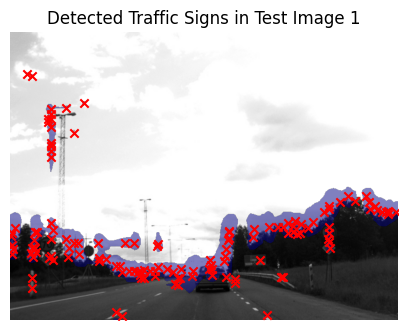

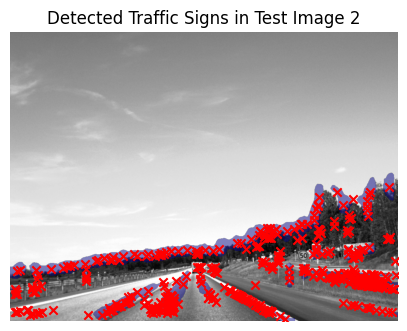

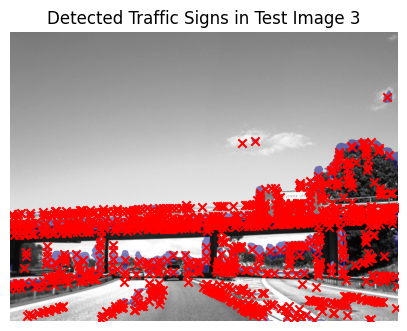

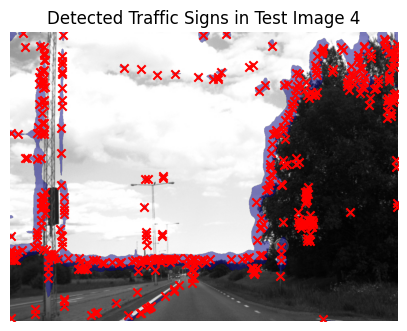

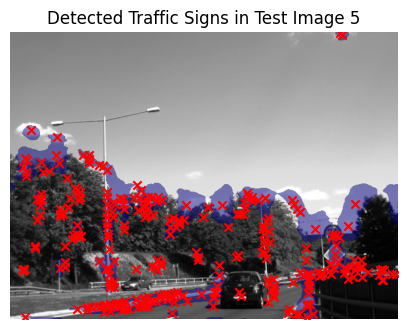

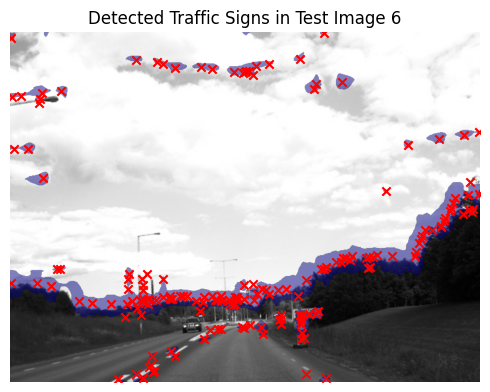

In [62]:
# Load and process all test images
images = load_images_as_grayscale('data/trafficsigns/test_images')

for i, image in enumerate(images):

    # Detect cell centers
    centers, thresholded_response = detector(image, w, best_f1_threshold)

    # Display the results
    thresholded_response_masked = np.where(thresholded_response, 1, np.nan)

    f, ax = plt.subplots(1, 1, figsize=(5, 5))
    ax.imshow(image, cmap='gray')
    ax.axis('off')

    ax.imshow(thresholded_response_masked, cmap='jet', alpha=0.5)
    ax.scatter(centers[1], centers[0], color='red', marker='x')
    ax.set_title(f'Detected Traffic Signs in Test Image {i+1}')
plt.tight_layout()
plt.show()

**Your answer:**

Applying the similarity filter to full test images of the road scene performs very poorly with an incredibly large number of detections being made on other elements of the test images. In most cases, the one or two traffic signs in the image are in fact detected, while sometimes they are not. This behaviour, combined with the strong patch-level F1 score, suggests that the filter is proficient at finding traffic signs on the patch level but performs poorly in a real road image. The main issue for using it on a full road image is that the complexity of the full image is so high that many other elements of the image gain a high similarity score regardless of if the content matches. As a result the detection centers become useless.

This behaviour is clearly observable from the masked overlay where in all test images, the overlay is concentrated on the treeline or bridge edges and poles. Comparing with the average positive patch image we can clearly attribute this behaviour to the intensity increasing from the bottom to the top of the reference patch. A gradient in intensity values with a clear vertical direction matches exactly with a treeline or bridge edges where the trees or bridges form a lower intensity contrast against the above sky with a high intensity. Beyond the treeline detections, we also observe this gradient matching behaviour in places like the road lines and road markings, where detections are also being made based on a low intensity bottom half and a high intensity upper half. This is especially apparent in test images 2, 3, 4, and 5.

It is precisely this gradient behaviour that makes the detector perform poorly on the test images, since the similarity does not "understand" that it is the traffic sign content we want to focus on detecting, but instead since the similarity is calculated from the entire patch image, the gradient in intensity is recognized more clearly than the content. As a result we receive patches with very high similarity, but without meaningful content. This is especially interesting since the detector performs very well on the positive and negative training patches. However, this is to be expected because in that case the patch images have been purposefully adjusted and cropped to make the positive and negative instances more clear. Such perfect cases do not necessarily exist in the test images.

In general, this is the problem when using an average positive patch representation as a reference image. Since the average dilutes the representation of the sign by including many different angles, lighting, and background, the final averaged patch includes very generalized shapes and intensities. In this case, the set of training images has unintentionally introduced background noise making the detection perform poorly. This is a general issue with this method, where the choice of training images makes a very large and potentially unintended impact on the detection result.

One possible way to prevent this behaviour is to instead tune the optimal threshold on precision scoring instead of F1 scoring. This would emphasize only making detections we are very sure about, potentially reducing the number of false positives. However, even with this addition, the number of false positives in a large image like our test images will still be high. For example, if the precision is 99% one could still get a hundred false positives in an image like test image 3 while we ideally only want 1 to 3 actual detections. This highlights the fundamental difference between this detection task and the cell detection task, which is the extreme imbalance between negative patches in an image and the positive ones. Making it fundamentally difficult to make only the handful of correct detections.

## Task 3: Church classification with SIFT features

In this task, you will extract SIFT (_scale-infavirant feature transform_) feature points for a set of images, and use them to classify test images.

SIFT feature points are a set of detected keypoints in an image with associated descriptors. The descriptors are constructed by accumulating gradient orientations $\theta$ weighted by magnitudes $m$ into a set of histograms, resulting in a $D$-dimensional descriptor. For standard SIFT in OpenCV, $D = 128$.

The objective is to classify a set of images of churches from different Swedish cities, using SIFT descriptors. You will generate a set of relevant keypoints and descriptors from all training images in `data/churches/church_training/` and create a classifier that tries to classify a new image by computing feature points for the new image, matching them to the feature points in the training data and letting each match vote for the correct church. The functions to extract features and do the matching are already provided.

In [ ]:
def extract_sift_features(image: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Use OpenCV's SIFT implementation to extract keypoints and descriptors from the input image.
    
    Args:
        image (np.ndarray): A 2D array representing the input grayscale image.
    Returns:
        Tuple[np.ndarray, np.ndarray]: A tuple containing the detected keypoints and their corresponding descriptors.
    """
    sift = cv2.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(image, None)
    return keypoints, descriptors

def match_descriptors(descriptors: np.ndarray, training_data: dict, ratio_thresh: float = 0.8) -> list:
    """
    Matches descriptors from the test image to the training descriptors using Lowe's ratio test.
    Returns the good matches.

    Args:
        descriptors (np.ndarray): The SIFT descriptors of the test image.
        training_data (dict): A dictionary containing the training descriptors and labels.
        ratio_thresh (float): The threshold for Lowe's ratio test (default is 0.8).
    Returns:
        list: A list of good matches that pass Lowe's ratio test.
    """
    bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
    matches = bf.knnMatch(descriptors.astype(np.float32), training_data['descriptors'].astype(np.float32), k=2)

    # Apply Lowe's ratio test
    good_matches = [m for m, n in matches if m.distance < ratio_thresh * n.distance]

    return good_matches


def visualize_sift_descriptors_on_image(image: np.ndarray, keypoints: list, descriptors: np.ndarray, scale: float = 100.0) -> Tuple[plt.Figure, plt.Axes]:
    """
    Visualizes SIFT keypoints and their corresponding descriptors on the input image, by drawing the keypoints and representing the descriptors as polar
    histograms around the keypoints on the image.

    Args:
        image (np.ndarray): The input grayscale image.
        keypoints: A list of SIFT keypoints detected in the image.
        descriptors: The corresponding SIFT descriptors for the keypoints.
        scale (float): A scaling factor for visualizing the descriptors (default is 100.0).

    Returns:
        Tuple[plt.Figure, plt.Axes]: A tuple containing the matplotlib figure and axes objects with the visualized keypoints and descriptors.
    """
    # Convert the grayscale image to BGR for visualization
    image_bgr = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

    # Loop through each keypoint and its descriptor
    for keypoint, descriptor in zip(keypoints, descriptors):
        # Draw the keypoint on the image
        x, y = int(keypoint.pt[0]), int(keypoint.pt[1])
        cv2.circle(image_bgr, (x, y), radius=3, color=(0, 255, 0), thickness=-1)

        # Visualize the descriptor as a polar histogram around the keypoint
        # SIFT descriptors are 128-dimensional, representing 4x4 spatial bins with 8 orientation bins each
        for i in range(4):
            for j in range(4):
                # Get the 8 orientation bins for this spatial bin
                orientation_bins = descriptor[i * 32 + j * 8:(i + 1) * 32 + (j + 1) * 8]
                # Normalize the orientation bins
                orientation_bins /= np.linalg.norm(orientation_bins) + 1e-6

                # Draw the polar histogram for this spatial bin
                for k in range(8):
                    angle = k * 45  # Each orientation bin corresponds to a 45-degree angle
                    magnitude = orientation_bins[k] * scale  # Scale the magnitude for visualization
                    end_x = int(x + magnitude * np.cos(np.radians(angle)))
                    end_y = int(y - magnitude * np.sin(np.radians(angle)))  # y-axis is inverted in image coordinates
                    cv2.line(image_bgr, (x, y), (end_x, end_y), color=(0, 0, 255), thickness=3)

    # Display the image with keypoints and descriptors
    f, ax = plt.subplots(1, 2, figsize=(10, 10))
    ax[0].imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
    ax[0].set_title('SIFT Keypoints and Descriptors Visualization')
    ax[0].axis('off')

    # Also add the drawn keypoints on the original grayscale image for comparison
    image_with_keypoints = cv2.drawKeypoints(image, keypoints, image_bgr, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    ax[1].imshow(image_with_keypoints, cmap='gray')
    ax[1].set_title('OpenCV Rich Keypoints')
    ax[1].axis('off')
    return f, ax

Let us visualize some of the churches and their SIFT keypoints and descriptors.

In [ ]:
# Visualize matches for the training data
training_data_path = 'data/churches/church_training/'
training_image_paths = glob(os.path.join(training_data_path, '*/*.jpg'))

for training_image_path in training_image_paths:
    training_image = cv2.imread(training_image_path, cv2.IMREAD_GRAYSCALE)
    keypoints, descriptors = extract_sift_features(training_image)

    # Visualize the SIFT descriptors on the training image
    idxs = np.random.choice(len(keypoints), min(500, len(keypoints)), replace=False)
    keypoints_sample = [keypoints[i] for i in idxs]
    descriptors_sample = descriptors[idxs]
    f, ax = visualize_sift_descriptors_on_image(training_image, keypoints_sample, descriptors_sample, scale=50)
    plt.show()


For this task, write a function use the `extract_sift_features` from the images to get keypoints and their features, and compile the training data into a dictionary with containing the keypoints, their features, as well as numeric labels and class names for each church.

In [ ]:
def create_training_data(training_folder: str) -> dict:
    """
    Extracts SIFT descriptors from all training images and returns the training data. 
    Collates the keypoints, descriptors, labels, and class names into a dictionary for later use in matching and classification.

    Args:
        training_folder (str): The path to the training data folder containing subfolders for each class.
    Returns:
        dict: A dictionary with structure
                {
                    'keypoints': np.ndarray of shape (N, 2) containing the (x, y) coordinates of keypoints,
                    'descriptors': np.ndarray of shape (N, D) containing the SIFT descriptors,
                    'labels': np.ndarray of shape (N,) containing the class labels for each descriptor,
                    'names': list of class names corresponding to the labels
                }
                where N is the total number of descriptors extracted from all training images, and D is the dimensionality of the SIFT descriptors.
    
    """
    # YOUR CODE HERE
    raise NotImplementedError()

Create a classifier that uses the supplied `match_descriptors` function to extract good matches to samples features in the training set. You do not need the keypoints in this case. Accumulate votes for each matching sample in the training set, and then let the highest number of votes be the classification.

In [ ]:

def classify_church(image: np.ndarray, training_data: dict) -> int:
    """
    Classifies a given image by matching its SIFT descriptors to stored training descriptors 
    and using a voting system to determine the most likely church.

    Args:
        image (np.ndarray): Test image to be classified.
        training_data (dict): Dictionary containing:
            - 'keypoints': np.ndarray of shape (N, 2) containing the (x, y) coordinates of keypoints,
            - 'descriptors': np.ndarray of shape (N, D) containing the SIFT descriptors,
            - 'labels': np.ndarray of shape (N,) containing the class labels for each descriptor,
            - 'names': list of class names corresponding to the labels

    Returns:
        int: Predicted label corresponding to the most likely church.
    """
    # YOUR CODE HERE
    raise NotImplementedError()

In [ ]:
# Load training data
training_data = create_training_data('data/churches/church_training/')

# Classify test images
test_images = glob('data/churches/church_test/*.jpg')

for image_path in test_images:
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    label = classify_church(image, training_data)
    class_name = training_data['names'][label]
    print(f'Image {os.path.basename(image_path)} classified as {class_name}')

